# Δ Proyecto Delta | Análisis de Hábitos de Compra en Instacart

## Contexto empresarial

Instacart es una plataforma de entrega de comestibles que conecta a los clientes con supermercados y tiendas de víveres. Comprender los hábitos de compra de los usuarios resulta fundamental para optimizar la experiencia de compra, mejorar las recomendaciones de productos y apoyar la toma de decisiones comerciales.

Para este proyecto se analizaron datos históricos de pedidos, productos y comportamiento de compra con el propósito de identificar patrones relevantes de consumo y generar información útil para el negocio.

## Objetivos

- Evaluar la calidad de los datos disponibles.
- Identificar y corregir valores ausentes y registros duplicados.
- Comprender los patrones de compra de los clientes.
- Analizar cuándo realizan pedidos los usuarios.
- Identificar productos y categorías con mayor demanda.
- Explorar hábitos de recompra.
- Generar visualizaciones que faciliten la interpretación de los resultados.
- Obtener hallazgos que apoyen decisiones basadas en datos.

## Conjuntos de datos utilizados

- `instacart_orders.csv`
- `products.csv`
- `order_products.csv`
- `aisles.csv`
- `departments.csv`

Preparamos los datasets necesarios para el trabajo

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt# importar librerías

In [ ]:
df_aisles = pd.read_csv("/datasets/aisles.csv", sep=';')
df_departments = pd.read_csv("/datasets/departments.csv", sep=';')
df_instacart = pd.read_csv("/datasets/instacart_orders.csv", sep=';')
df_order_products = pd.read_csv("/datasets/order_products.csv", sep=';')
df_products = pd.read_csv("/datasets/products.csv", sep=';')# leer conjuntos de datos en los DataFrames

## Exploración inicial de la estructura de categorías

Se realizó una primera revisión de la tabla de pasillos con el fin de comprender la organización de los productos dentro de la plataforma. La información disponible muestra 134 categorías de pasillo únicas, cada una identificada mediante un código y su respectiva descripción.

La ausencia de valores faltantes y la correcta definición de los tipos de datos indican que esta tabla presenta una buena calidad de información. Esto facilitará posteriormente la asociación de productos con sus categorías de compra y permitirá analizar qué tipos de artículos concentran una mayor actividad dentro de la plataforma.

In [ ]:
df_aisles.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


## Exploración de la estructura de departamentos

Se revisó la tabla de departamentos para comprender cómo se agrupan los productos dentro de la plataforma. La información disponible muestra 21 departamentos distintos, cada uno identificado mediante un código único y su respectiva categoría comercial.

La tabla no presenta valores ausentes ni inconsistencias visibles, lo que permite utilizarla con confianza en análisis posteriores. Esta información será especialmente útil para identificar qué departamentos concentran una mayor cantidad de productos, pedidos o niveles de recompra, proporcionando una visión más amplia de los hábitos de compra de los clientes.

In [ ]:
df_departments.info() # mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


## Exploración de la base de pedidos

La tabla de pedidos constituye el núcleo del análisis, ya que contiene información sobre cuándo compran los clientes, con qué frecuencia realizan pedidos y cuánto tiempo transcurre entre una compra y la siguiente. La revisión inicial muestra cerca de 479 mil pedidos registrados, proporcionando una muestra suficientemente amplia para identificar patrones de comportamiento y tendencias de consumo.

En términos generales, la estructura de los datos es consistente y las variables relacionadas con los pedidos no presentan valores faltantes. Sin embargo, se observa que la columna `days_since_prior_order` contiene registros ausentes. Este comportamiento es esperado, ya que los clientes que realizan su primer pedido no cuentan con una compra previa que permita calcular el intervalo entre pedidos.

La calidad general de la información sugiere que la tabla se encuentra en condiciones adecuadas para analizar la frecuencia de compra, los horarios de mayor actividad, los días con más pedidos y los hábitos de recompra de los clientes de Instacart.

In [ ]:
df_instacart.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


## Exploración de los productos incluidos en los pedidos
Esta tabla contiene el mayor volumen de información del proyecto, con más de 4,5 millones de registros que relacionan cada pedido con los productos adquiridos. Gracias a esta información será posible reconstruir el contenido de las compras realizadas por los clientes y analizar con mayor detalle sus hábitos de consumo.

In [ ]:
df_order_products.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Exploración del catálogo de productos
Se revisó la tabla de productos para comprender el alcance del catálogo disponible en la plataforma y verificar la calidad de la información asociada a cada artículo. La base contiene cerca de 50 mil productos únicos, cada uno vinculado a una categoría de pasillo y a un departamento comercial, lo que permitirá analizar posteriormente qué tipos de productos generan una mayor demanda entre los clientes.

In [ ]:
df_products.info()# mostrar información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


## Identificación de pedidos duplicados
Durante la revisión de la calidad de los datos se detectó la presencia de pedidos con identificadores repetidos, una situación que requiere atención antes de iniciar cualquier análisis de comportamiento de compra. Dado que cada pedido debería estar representado por un identificador único, la existencia de registros duplicados podría generar distorsiones en métricas clave como el número total de pedidos, la frecuencia de compra y los patrones de consumo de los clientes.

In [ ]:


dup_orders = df_instacart[df_instacart.duplicated(subset=['order_id'])]

print(dup_orders)


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

## Investigación de los pedidos registrados el miércoles a las 2:00 a. m.
Debido a que los pedidos duplicados identificados anteriormente compartían el mismo día y la misma hora de registro, se decidió analizar todos los pedidos realizados los miércoles a las 2:00 a. m. para determinar si existía algún patrón inusual en los datos.

In [ ]:
# Verificacion de todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
pedidos_miercoles_2am = df_instacart[
    (df_instacart['order_dow'] == 3) &
    (df_instacart['order_hour_of_day'] == 2)
]
print(pedidos_miercoles_2am)

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

Tras identificar registros repetidos en la base de datos, se eliminaron los pedidos duplicados para asegurar que cada compra estuviera representada una única vez.

In [ ]:

# Eliminacion de  los pedidos duplicados
df_instacart.drop_duplicates(subset=['order_id'], inplace=True)


Se realizó una validación posterior al proceso de limpieza para confirmar que no permanecieran pedidos duplicados en la base de datos. Los resultados indican que todos los registros repetidos fueron eliminados correctamente, permitiendo continuar el análisis sobre una versión depurada y más confiable de la información.

In [ ]:
# Verificación de filas duplicadas

dup_orders_check = df_instacart[df_instacart.duplicated(subset=['order_id'])]

print(dup_orders_check)


Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


## Confirmación de la unicidad de los pedidos

Se realizó una comprobación adicional sobre los identificadores de pedido para asegurar que cada orden estuviera registrada una sola vez dentro del conjunto de datos. La verificación confirmó que no existen identificadores duplicados, lo que garantiza la consistencia de la información utilizada en los análisis posteriores.

In [ ]:

dup_order_ids = df_instacart[df_instacart['order_id'].duplicated()]
print(dup_order_ids)



Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


## Verificación de registros duplicados en el catálogo de productos

Se revisó el catálogo de productos para identificar posibles registros completamente duplicados que pudieran afectar la calidad del análisis. La validación confirmó que no existen filas repetidas en esta tabla, lo que indica que cada producto está representado de forma única dentro del conjunto de datos.

Esta revisión permite continuar con confianza en los análisis relacionados con productos, categorías y patrones de compra.

In [ ]:
# Verificación de filas totalmente duplicadas

dup_full_products = df_products[df_products.duplicated()]

print(dup_full_products)


Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Se revisaron los identificadores de producto para confirmar que cada artículo del catálogo estuviera representado una única vez. La validación mostró que no existen productos con identificadores duplicados, lo que garantiza la integridad del catálogo y permite realizar análisis confiables sobre popularidad de productos, categorías y patrones de compra.

In [ ]:
# Revisión para ID de productos duplicados

dup_product_ids = df_products[df_products['product_id'].duplicated()]

print(dup_product_ids)


Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


## Revisión de nombres de productos duplicados

Se analizaron los nombres de los productos para identificar artículos que pudieran estar registrados más de una vez dentro del catálogo. La revisión detectó 104 productos con nombres duplicados, lo que indica que distintos identificadores de producto comparten la misma descripción comercial.

Este hallazgo requiere una revisión más detallada para determinar si se trata de productos realmente duplicados o de artículos diferentes que, por alguna razón, utilizan el mismo nombre. Comprender estas diferencias será importante para evitar interpretaciones incorrectas al analizar la popularidad de productos y los patrones de compra de los clientes.

In [ ]:
dup_product_names = df_products[
    df_products['product_name'].notna() &
    df_products['product_name'].str.upper().duplicated()
]

print(dup_product_names)

       product_id                                     product_name  aisle_id  \
2058         2059                                  Biotin 1000 Mcg        47   
5455         5456                 Green Tea With Ginseng and Honey        96   
5558         5559                           Cream Of Mushroom Soup        69   
7558         7559                        Cinnamon Rolls with Icing       105   
9037         9038                           American Cheese slices        21   
...           ...                                              ...       ...   
49689       49690                    HIGH PERFORMANCE ENERGY DRINK        64   
49690       49691                    ORIGINAL PANCAKE & WAFFLE MIX       130   
49691       49692  ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR       130   
49692       49693                           SPRING WATER BODY WASH       127   
49693       49694                          BURRITO- STEAK & CHEESE        38   

       department_id  
2058            

Se realizó una comprobación adicional para determinar si existían nombres de productos repetidos de forma exacta dentro del catálogo. Los resultados muestran que no hay duplicados directos entre los registros con nombre disponible, lo que indica que cada producto mantiene una denominación única.

In [ ]:
# duplicados de productos no faltantes

dup_names = df_products[df_products['product_name'].notna() & df_products['product_name'].duplicated()]
print(dup_names)


Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Se revisó la tabla de departamentos para comprobar si existían registros completamente duplicados que pudieran afectar la organización y el análisis de las categorías de productos. La validación confirmó que cada departamento se encuentra registrado una única vez dentro de la base de datos.

In [ ]:
# filas totalmente duplicadas
dup_departments_full = df_departments[df_departments.duplicated()]
print(dup_departments_full)


Empty DataFrame
Columns: [department_id, department]
Index: []


Se verificó que cada departamento estuviera asociado a un único identificador dentro de la base de datos. La revisión confirmó que no existen IDs duplicados, lo que garantiza una estructura consistente para clasificar los productos y facilita los análisis posteriores por departamento.

In [ ]:
dup_department_ids = df_departments[df_departments['department_id'].duplicated()]
print(dup_department_ids)#IDs duplicadas de departamentos

Empty DataFrame
Columns: [department_id, department]
Index: []


Se revisó la tabla de pasillos para identificar posibles registros completamente duplicados que pudieran afectar la clasificación de los productos. La validación confirmó que no existen filas repetidas, lo que indica que cada pasillo está registrado de forma única dentro de la base de datos.

In [ ]:
dup_aisles_full = df_aisles[df_aisles.duplicated()]
print(dup_aisles_full)
# Revisación si hay filas totalmente duplicadas

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


Se revisaron los identificadores de los pasillos para confirmar que cada categoría estuviera registrada una sola vez dentro de la base de datos. La validación mostró que no existen IDs duplicados, lo que garantiza una clasificación consistente de los productos y facilita los análisis posteriores por categorías de compra.

In [ ]:

dup_aisle_ids = df_aisles[df_aisles['aisle_id'].duplicated()]
print(dup_aisle_ids)
# IDs duplicadas de pasillos

Empty DataFrame
Columns: [aisle_id, aisle]
Index: []


Analizamos la tabla que relaciona los pedidos con los productos adquiridos para identificar posibles registros completamente duplicados. La validación confirmó que no existen filas repetidas, lo que indica que cada producto asociado a un pedido se encuentra registrado de manera única dentro del conjunto de datos.

In [ ]:
# filas totalmente duplicadas

dup_order_products_full = df_order_products[df_order_products.duplicated()]
print(dup_order_products_full)


Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


Se realizó una comprobación adicional para detectar registros repetidos bajo distintos criterios dentro de la tabla de productos por pedido. La revisión confirmó que no existen duplicados ocultos o inconsistencias relacionadas con la combinación de las variables analizadas.

In [ ]:
# cualquier otro duplicado engañoso

dup_full = df_order_products[df_order_products.duplicated(keep=False)]
print(dup_full)



Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


## Identificación de productos con información incompleta

Se revisó el catálogo de productos para identificar registros con información faltante en el nombre del producto. La exploración reveló 1.258 productos sin descripción disponible, lo que representa una proporción relevante dentro del catálogo total.

Además, se observa que todos estos registros están asociados al mismo pasillo y departamento, lo que sugiere que los valores ausentes no ocurren de manera aleatoria y podrían corresponder a una categoría específica de productos o a una característica particular del conjunto de datos. Antes de continuar con el análisis, será necesario investigar estos registros para determinar el tratamiento más adecuado.

In [ ]:

missing_product_name = df_products[df_products['product_name'].isna()]
print(missing_product_name)
#valores ausentes en la columna 'product_name'

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Se profundizó en la revisión de los productos con nombres faltantes para identificar posibles patrones dentro del catálogo. Los resultados muestran que los 1.258 registros sin nombre se concentran exclusivamente en el mismo pasillo (`aisle_id = 100`), sin excepciones.

Este hallazgo sugiere que los valores ausentes no corresponden a errores distribuidos aleatoriamente en la base de datos, sino a una característica específica de un grupo particular de productos. Conocer esta concentración resulta útil para decidir cómo tratar estos registros en etapas posteriores del análisis y para evitar interpretaciones incorrectas sobre la composición del catálogo de productos.

In [ ]:
# Filtramos productos con nombre faltante
missing_names = df_products[df_products['product_name'].isna()]

# Verificación si TODOS esos faltantes están en el pasillo 100
all_in_aisle_100 = (missing_names['aisle_id'] == 100).all()

# Conteos útiles para reportar
total_missing = len(missing_names)
missing_in_100 = (missing_names['aisle_id'] == 100).sum()
missing_not_in_100 = total_missing - missing_in_100

print("Total product_name faltantes:", total_missing)
print("Faltantes con aisle_id = 100:", missing_in_100)
print("Faltantes con aisle_id != 100:", missing_not_in_100)
print("¿Todos están en aisle_id = 100?:", all_in_aisle_100)

missing_outside_100 = missing_names[missing_names['aisle_id'] != 100]
print(missing_outside_100)


Total product_name faltantes: 1258
Faltantes con aisle_id = 100: 1258
Faltantes con aisle_id != 100: 0
¿Todos están en aisle_id = 100?: True
Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Se amplió la revisión de los registros con nombres de producto ausentes para determinar si también compartían una misma clasificación comercial. Los resultados muestran que los 1.258 productos sin nombre pertenecen al mismo departamento (`department_id = 21`).

In [ ]:
# Filtramos productos con nombre faltante
missing_names = df_products[df_products['product_name'].isna()]

# Verificacón si TODOS esos faltantes están en el departamento 21
all_in_dept_21 = (missing_names['department_id'] == 21).all()

# Conteos útiles para reportar
total_missing = len(missing_names)
missing_in_21 = (missing_names['department_id'] == 21).sum()
missing_not_in_21 = total_missing - missing_in_21

print("Total product_name faltantes:", total_missing)
print("Faltantes con department_id = 21:", missing_in_21)
print("Faltantes con department_id != 21:", missing_not_in_21)
print("¿Todos están en department_id = 21?:", all_in_dept_21)

missing_outside_21 = missing_names[missing_names['department_id'] != 21]
print(missing_outside_21)

Total product_name faltantes: 1258
Faltantes con department_id = 21: 1258
Faltantes con department_id != 21: 0
¿Todos están en department_id = 21?: True
Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


Para comprender mejor los registros con nombres de producto ausentes, se revisaron las categorías a las que pertenecían. Los resultados muestran que todos estos productos están asociados al pasillo denominado **"missing"** y al departamento **"missing"**.

In [ ]:

aisle_100 = df_aisles[df_aisles['aisle_id'] == 100]
dept_21 = df_departments[df_departments['department_id'] == 21]

print(aisle_100)
print(dept_21)


    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


## Tratamiento de productos con nombres ausentes
Tras identificar que los productos sin nombre pertenecían a categorías marcadas como "missing", se optó por reemplazar los valores ausentes por la etiqueta **"Unknown"**. Esta decisión permite conservar los registros dentro del análisis sin perder información asociada a pedidos, categorías o departamentos.

In [ ]:

df_products['product_name'] = df_products['product_name'].fillna('Unknown')
print(df_products)


       product_id                                       product_name  \
0               1                         Chocolate Sandwich Cookies   
1               2                                   All-Seasons Salt   
2               3               Robust Golden Unsweetened Oolong Tea   
3               4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4               5                          Green Chile Anytime Sauce   
...           ...                                                ...   
49689       49690                      HIGH PERFORMANCE ENERGY DRINK   
49690       49691                      ORIGINAL PANCAKE & WAFFLE MIX   
49691       49692    ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR   
49692       49693                             SPRING WATER BODY WASH   
49693       49694                            BURRITO- STEAK & CHEESE   

       aisle_id  department_id  
0            61             19  
1           104             13  
2            94              7  
3  

Ejecutamos una búsqueda de valores ausentes

In [ ]:
missing_orders = df_instacart.isna().sum()
print(missing_orders)
# Encuentra los valores ausentes

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


Se investigaron los registros con valores ausentes en la variable que mide los días transcurridos desde el pedido anterior. La revisión confirmó que todos estos casos corresponden al primer pedido realizado por cada cliente.

Dado que un cliente no tiene una compra previa antes de su primer pedido, la ausencia de este dato es coherente con la lógica del negocio y no representa un problema de calidad en la información. Por esta razón, estos valores pueden mantenerse sin modificaciones durante el análisis.

In [ ]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
missing_days = df_instacart[df_instacart['days_since_prior_order'].isna()]

not_first_order_missing = missing_days[missing_days['order_number'] != 1]

print("Total NaN en days_since_prior_order:", len(missing_days))
print("NaN que NO son primer pedido (order_number != 1):", len(not_first_order_missing))
print(not_first_order_missing.head())

Total NaN en days_since_prior_order: 28817
NaN que NO son primer pedido (order_number != 1): 0
Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


En este momento evaluamos  la calidad de la información en la tabla que relaciona pedidos y productos con el fin de identificar posibles registros incompletos. La revisión mostró que los valores ausentes se concentran exclusivamente en la variable `add_to_cart_order`, mientras que las demás columnas no presentan faltantes.

In [ ]:

missing_order_products = df_order_products.isna().sum()
print(missing_order_products)# Encontramos los valores ausentes


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


Antes de decidir cómo tratar los valores ausentes de `add_to_cart_order`, se revisó el rango de valores registrados en esta variable. Los resultados muestran que la posición de un producto dentro del carrito varía entre 1 y 64 artículos por pedido.

Esta revisión permite comprender mejor la estructura de los pedidos y proporciona un contexto útil para analizar los registros que presentan valores faltantes en esta variable.

In [ ]:

min_add = df_order_products['add_to_cart_order'].min(skipna=True)
max_add = df_order_products['add_to_cart_order'].max(skipna=True)

print("Mínimo add_to_cart_order (sin NaN):", min_add)
print("Máximo add_to_cart_order (sin NaN):", max_add)


Mínimo add_to_cart_order (sin NaN): 1.0
Máximo add_to_cart_order (sin NaN): 64.0


## Identificación de pedidos con posiciones de carrito ausentes

Se identificaron los pedidos que contienen valores ausentes en la variable `add_to_cart_order` con el fin de analizar si estos registros comparten algún patrón en común. Esta revisión permitirá investigar las características de los pedidos afectados y comprender mejor el origen de los datos faltantes antes de decidir cómo tratarlos.

El análisis de estos pedidos será importante para determinar si los valores ausentes corresponden a una situación específica del proceso de compra o a una inconsistencia dentro del conjunto de datos.

In [ ]:

missing_cart_order_ids = df_order_products.loc[
    df_order_products['add_to_cart_order'].isna(),
    'order_id'
].unique()

print(missing_cart_order_ids)


[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


Se examinó el número de productos asociados a los pedidos que presentan valores ausentes en la variable `add_to_cart_order`. Los resultados muestran que estos pedidos no comparten un tamaño mínimo específico, ya que existen casos con un solo producto y otros con decenas de artículos.

Este comportamiento indica que los valores ausentes no parecen estar relacionados exclusivamente con pedidos muy grandes o con una cantidad

In [ ]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
# Filtra solo las filas con add_to_cart_order ausente
missing_cart = df_order_products[df_order_products['add_to_cart_order'].isna()]

# Agrupa por order_id y cuenta product_id en cada pedido
count_products_per_order = missing_cart.groupby('order_id')['product_id'].count()

# Valor mínimo del conteo
min_count = count_products_per_order.min()

print(count_products_per_order)
print("Valor mínimo del conteo:", min_count)


order_id
9310        1
61355      63
102236     31
129627      5
165801      6
           ..
2999801     6
3125735    22
3308010    51
3347453     7
3383594     5
Name: product_id, Length: 70, dtype: int64
Valor mínimo del conteo: 1


Tras analizar los registros con valores faltantes en `add_to_cart_order`, se decidió asignar un valor identificador específico para conservar estas observaciones dentro del conjunto de datos sin alterar el resto de la información. Posteriormente, la variable fue convertida a formato entero para mantener la consistencia de los tipos de datos.

In [ ]:
# Remplazamos los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

df_order_products['add_to_cart_order'] = (
    df_order_products['add_to_cart_order']
    .fillna(999)
    .astype(int)
)


Se revisaron las variables relacionadas con el momento en que se realizaron los pedidos para verificar que sus valores estuvieran dentro de los rangos esperados. La evaluación confirmó que las horas de compra se encuentran correctamente registradas entre 0 y 23, mientras que los días de la semana se encuentran dentro del rango de 0 a 6.

In [ ]:
# 1) Revisión rápida: mínimos y máximos
print("order_hour_of_day min/max:", df_instacart['order_hour_of_day'].min(), df_instacart['order_hour_of_day'].max())
print("order_dow min/max:", df_instacart['order_dow'].min(), df_instacart['order_dow'].max())

# 2) Detecta valores fuera de rango
bad_hours = df_instacart[(df_instacart['order_hour_of_day'] < 0) | (df_instacart['order_hour_of_day'] > 23)]
bad_dow = df_instacart[(df_instacart['order_dow'] < 0) | (df_instacart['order_dow'] > 6)]

# 3) Muestra cuántos están mal y cuáles son (si hay)
print("Filas fuera de rango en order_hour_of_day:", len(bad_hours))
print(bad_hours)

print("Filas fuera de rango en order_dow:", len(bad_dow))
print(bad_dow)

order_hour_of_day min/max: 0 23
order_dow min/max: 0 6
Filas fuera de rango en order_hour_of_day: 0
Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []
Filas fuera de rango en order_dow: 0
Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


## Distribución de pedidos por hora del día

La actividad de compra presenta un patrón muy marcado a lo largo del día. Durante la madrugada se registra el menor número de usuarios realizando pedidos, especialmente entre las 2:00 a. m. y las 5:00 a. m.

A partir de las 7:00 a. m. la actividad comienza a incrementarse de forma sostenida y alcanza su punto máximo entre las 10:00 a. m. y las 3:00 p. m., donde se concentra la mayor parte de los clientes realizando compras en la plataforma.

Después de las 4:00 p. m. se observa una disminución gradual en el número de usuarios activos, manteniéndose una tendencia descendente durante la noche. Estos resultados sugieren que la mayoría de las compras se realizan durante las horas diurnas, especialmente alrededor del mediodía y las primeras horas de la tarde.

    order_hour_of_day  n_people
0                   0      2991
1                   1      1671
2                   2       958
3                   3       744
4                   4       735
5                   5      1281
6                   6      3757
7                   7     10993
8                   8     20268
9                   9     28112
10                 10     32195
11                 11     32660
12                 12     31754
13                 13     32433
14                 14     32797
15                 15     32894
16                 16     31579
17                 17     26825
18                 18     21795
19                 19     17026
20                 20     12891
21                 21      9806
22                 22      7670
23                 23      5167


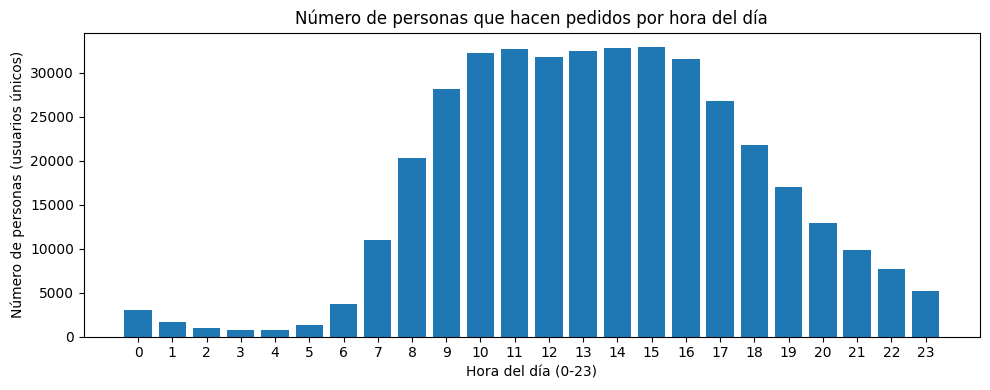

In [ ]:
people_per_hour_df = (
    df_instacart
    .groupby('order_hour_of_day', as_index=False)['user_id']
    .nunique()
    .rename(columns={'user_id': 'n_people'})
    .sort_values('order_hour_of_day')
)

print(people_per_hour_df)

plt.figure(figsize=(10, 4))
plt.bar(people_per_hour_df['order_hour_of_day'], people_per_hour_df['n_people'])
plt.title('Número de personas que hacen pedidos por hora del día')
plt.xlabel('Hora del día (0-23)')
plt.ylabel('Número de personas (usuarios únicos)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()



## Distribución de pedidos por día de la semana

La cantidad de pedidos no se distribuye de manera uniforme a lo largo de la semana. Los mayores volúmenes de compra se registran durante el domingo y el lunes, con más de 80 mil pedidos en cada caso.

A partir del martes se observa una disminución en la actividad, manteniéndose niveles relativamente estables entre miércoles, jueves, viernes y sábado. Aunque existen diferencias entre estos días, ninguna alcanza los niveles observados al inicio de la semana.

Estos resultados sugieren que una parte importante de los clientes realiza sus compras al comienzo de la semana, concentrando la mayor demanda de la plataforma durante los domingos y lunes.

   order_dow  n_orders   day_name
0          0     84090    Domingo
1          1     82185      Lunes
2          2     65833     Martes
3          3     60897  Miércoles
4          4     59810     Jueves
5          5     63488    Viernes
6          6     62649     Sábado


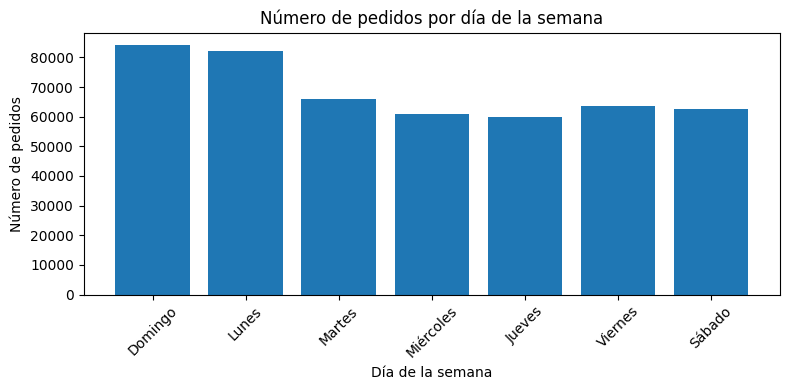

In [ ]:
dow_names = {
    0: 'Domingo',
    1: 'Lunes',
    2: 'Martes',
    3: 'Miércoles',
    4: 'Jueves',
    5: 'Viernes',
    6: 'Sábado'
}

orders_per_dow_df = (
    df_instacart['order_dow']
    .value_counts()
    .sort_index()
    .rename_axis('order_dow')
    .reset_index(name='n_orders')
)

orders_per_dow_df['day_name'] = orders_per_dow_df['order_dow'].map(dow_names)

print(orders_per_dow_df)

plt.figure(figsize=(8, 4))
plt.bar(orders_per_dow_df['day_name'], orders_per_dow_df['n_orders'])
plt.title('Número de pedidos por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Tiempo transcurrido entre pedidos

La distribución de días entre compras muestra que la mayoría de los clientes vuelve a realizar un pedido en un período relativamente corto, concentrándose principalmente durante la primera semana después de la compra anterior.

Además, se observa un pico muy marcado en los 30 días de espera, lo que indica que una proporción importante de usuarios realiza compras aproximadamente una vez al mes. Este comportamiento sugiere la coexistencia de distintos patrones de consumo dentro de la plataforma: clientes que compran con frecuencia y otros que siguen ciclos de compra más espaciados.

Por otro lado, los valores ausentes identificados anteriormente corresponden a primeros pedidos, por lo que no afectan la interpretación de esta distribución.

Valores faltantes (NaN) en days_since_prior_order: 28817
Tiempo mínimo de espera (días): 0.0
Tiempo máximo de espera (días): 30.0


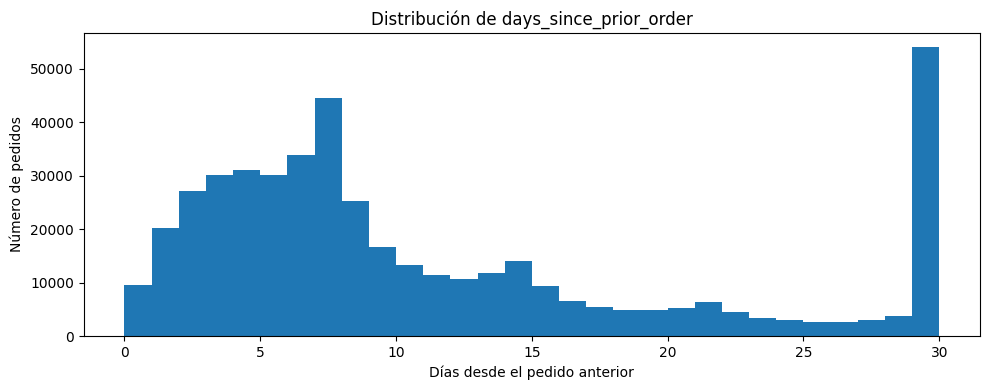

In [ ]:

import matplotlib.pyplot as plt

# 1) Revisa cuántos valores faltantes hay (NaN)
n_missing = df_instacart['days_since_prior_order'].isna().sum()
print("Valores faltantes (NaN) en days_since_prior_order:", n_missing)

# 2) Crea una versión sin NaN para analizar tiempos reales de espera
wait_times = df_instacart['days_since_prior_order'].dropna()

# 3) Valores mínimo y máximo (ignorando NaN)
min_wait = wait_times.min()
max_wait = wait_times.max()

print("Tiempo mínimo de espera (días):", min_wait)
print("Tiempo máximo de espera (días):", max_wait)

# 4) Gráfica de distribución (histograma)
plt.figure(figsize=(10, 4))
plt.hist(wait_times, bins=30)
plt.title("Distribución de days_since_prior_order")
plt.xlabel("Días desde el pedido anterior")
plt.ylabel("Número de pedidos")
plt.tight_layout()
plt.show()

## Comparación de los pedidos por hora: miércoles vs. sábado
Los patrones de compra son bastante similares entre ambos días. En los dos casos, la actividad comienza a aumentar durante la mañana, alcanza su punto máximo entre las primeras horas de la tarde y luego disminuye gradualmente durante la noche.

Sin embargo, el sábado registra un volumen ligeramente superior de pedidos, con 62.649 órdenes frente a las 60.897 observadas el miércoles. También se aprecia que la hora de mayor actividad ocurre un poco antes el sábado, alcanzando su máximo a las 2:00 p. m., mientras que el miércoles el pico se presenta a las 3:00 p. m.

En general, los resultados muestran que la mayor parte de las compras se concentra entre las 10:00 a. m. y las 4:00 p. m., independientemente del día analizado.

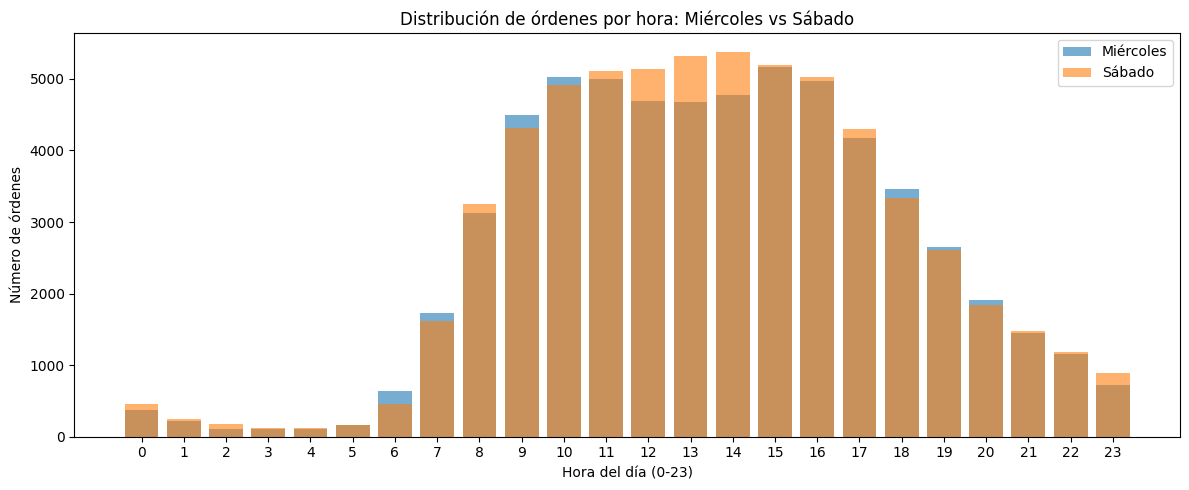

Total órdenes miércoles: 60897
Total órdenes sábado: 62649
Hora pico miércoles: 15 con 5163 órdenes
Hora pico sábado: 14 con 5375 órdenes


In [ ]:
import matplotlib.pyplot as plt

# (Opcional pero recomendado) asegurar que no haya order_id duplicados en orders
df_instacart = df_instacart.drop_duplicates(subset=['order_id'])

# Conteos por hora para cada día
wed = df_instacart[df_instacart['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sat = df_instacart[df_instacart['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

# Asegurar que existan todas las horas 0-23 (si falta alguna, se pone 0)
hours = range(24)
wed = wed.reindex(hours, fill_value=0)
sat = sat.reindex(hours, fill_value=0)

# Gráfico (barras superpuestas con transparencia)
plt.figure(figsize=(12, 5))
plt.bar(hours, wed, alpha=0.6, label='Miércoles')
plt.bar(hours, sat, alpha=0.6, label='Sábado')
plt.xticks(hours)
plt.title('Distribución de órdenes por hora: Miércoles vs Sábado')
plt.xlabel('Hora del día (0-23)')
plt.ylabel('Número de órdenes')
plt.legend()
plt.tight_layout()
plt.show()

# Números clave para describir diferencias
print("Total órdenes miércoles:", int(wed.sum()))
print("Total órdenes sábado:", int(sat.sum()))
print("Hora pico miércoles:", int(wed.idxmax()), "con", int(wed.max()), "órdenes")
print("Hora pico sábado:", int(sat.idxmax()), "con", int(sat.max()), "órdenes")

La distribución del número de pedidos por cliente muestra que la mayoría de los usuarios realiza pocas compras dentro del período analizado. Más de 55 mil clientes registran un solo pedido, mientras que la cantidad de usuarios disminuye progresivamente a medida que aumenta el número de compras realizadas.

In [ ]:

df_instacart = df_instacart.drop_duplicates(subset=['order_id'])

# 1) Cuántos pedidos hizo cada cliente (user_id)
orders_per_user = df_instacart.groupby('user_id')['order_id'].nunique()

# 2) Distribución: cuántos clientes tienen 1 pedido, 2 pedidos, 3 pedidos, etc.
dist_orders_per_user = orders_per_user.value_counts().sort_index()

print(dist_orders_per_user)


1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
11     1308
12      947
13      703
14      512
15      437
16      263
17      184
18      121
19       85
20       52
21       22
22       23
23       19
24        3
25        1
26        1
28        1
Name: order_id, dtype: int64


## Distribución del número de pedidos por cliente

La distribución confirma que la mayoría de los usuarios realiza pocos pedidos dentro de la plataforma. Los clientes con un solo pedido constituyen el grupo más numeroso, y la cantidad de usuarios disminuye progresivamente a medida que aumenta el número de compras realizadas.

El gráfico muestra una fuerte concentración en los primeros niveles de compra y una larga cola formada por clientes recurrentes que realizan pedidos de manera frecuente. Aunque estos usuarios representan una proporción menor de la base total de clientes, su actividad contribuye significativamente al volumen general de pedidos.

Este comportamiento es característico de muchos negocios de comercio electrónico, donde una gran parte de los usuarios realiza compras ocasionales mientras que un grupo más reducido mantiene una relación de compra recurrente con la plataforma.

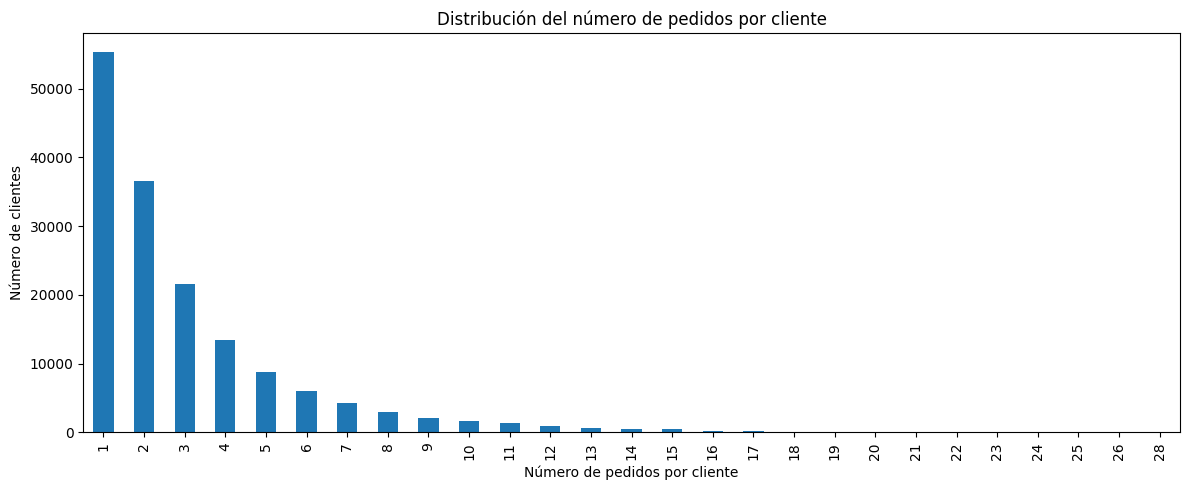

In [ ]:

dist_orders_per_user.plot(kind='bar', figsize=(12, 5))
plt.title('Distribución del número de pedidos por cliente')
plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Número de clientes')
plt.tight_layout()
plt.show()


## Productos más populares de la plataforma
El análisis de los productos con mayor número de pedidos muestra un claro predominio de frutas y verduras frescas dentro de la plataforma. Los dos artículos más solicitados fueron **Banana** y **Bag of Organic Bananas**, superando las 66 mil y 53 mil órdenes respectivamente.

Además, gran parte del ranking está compuesto por productos frescos y orgánicos, incluyendo fresas, espinacas, aguacates, limones, cebollas, ajo y manzanas. Este patrón sugiere que los clientes utilizan Instacart con frecuencia para abastecerse de productos de consumo habitual y alimentos perecederos.

In [ ]:
top20_products = (
    df_order_products['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top20_products.columns = ['product_id', 'n_orders']

top20_products = top20_products.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

print(top20_products[['product_id', 'product_name', 'n_orders']])

    product_id              product_name  n_orders
0        24852                    Banana     66050
1        13176    Bag of Organic Bananas     53297
2        21137      Organic Strawberries     37039
3        21903      Organic Baby Spinach     33971
4        47209      Organic Hass Avocado     29773
5        47766           Organic Avocado     24689
6        47626               Large Lemon     21495
7        16797              Strawberries     20018
8        26209                     Limes     19690
9        27845        Organic Whole Milk     19600
10       27966       Organic Raspberries     19197
11       22935      Organic Yellow Onion     15898
12       24964            Organic Garlic     15292
13       45007          Organic Zucchini     14584
14       39275       Organic Blueberries     13879
15       49683            Cucumber Kirby     13675
16       28204        Organic Fuji Apple     12544
17        5876             Organic Lemon     12232
18        8277  Apple Honeycris

El gráfico muestra una distribución asimétrica hacia la derecha, donde predominan los pedidos pequeños y medianos, mientras que los pedidos muy grandes son mucho menos comunes. Aunque existen compras con una cantidad considerable de productos, estos casos representan una proporción reducida del total.

En general, los resultados sugieren que la mayoría de los clientes utiliza la plataforma para realizar compras moderadas y recurrentes, más que para abastecimientos excepcionalmente grandes.

Promedio: 10.098983215049127
Mediana: 8.0
Moda: 5


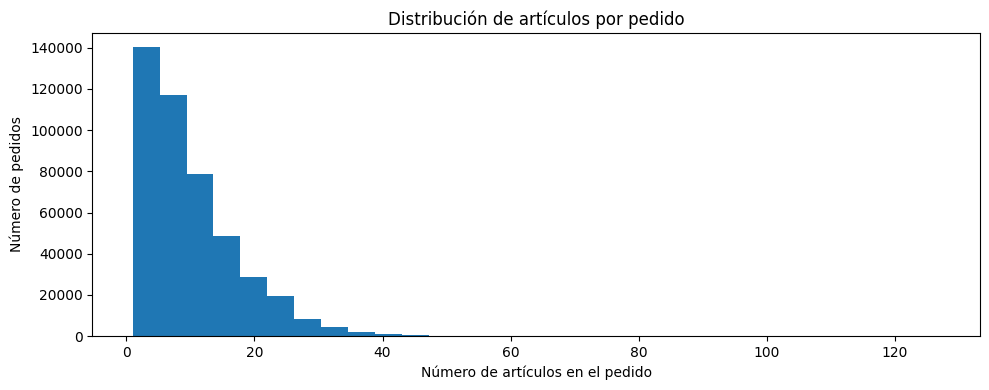

In [ ]:
items_per_order = df_order_products.groupby('order_id').size()

mean_items = items_per_order.mean()
median_items = items_per_order.median()
mode_items = items_per_order.value_counts().idxmax()

print("Promedio:", mean_items)
print("Mediana:", median_items)
print("Moda:", mode_items)

plt.figure(figsize=(10, 4))
plt.hist(items_per_order, bins=30)
plt.title('Distribución de artículos por pedido')
plt.xlabel('Número de artículos en el pedido')
plt.ylabel('Número de pedidos')
plt.tight_layout()
plt.show()


## Productos con mayor nivel de recompra

Los productos que lideran las recompensas coinciden en gran medida con los artículos más populares de la plataforma. Las bananas, fresas, aguacates, espinacas y otros productos frescos encabezan la lista de productos que los clientes vuelven a comprar con mayor frecuencia.

In [ ]:
top20_reordered = (
    df_order_products[df_order_products['reordered'] == 1]['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top20_reordered.columns = ['product_id', 'n_reordered']

top20_reordered = top20_reordered.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

print(top20_reordered[['product_id', 'product_name', 'n_reordered']])

    product_id              product_name  n_reordered
0        24852                    Banana        55763
1        13176    Bag of Organic Bananas        44450
2        21137      Organic Strawberries        28639
3        21903      Organic Baby Spinach        26233
4        47209      Organic Hass Avocado        23629
5        47766           Organic Avocado        18743
6        27845        Organic Whole Milk        16251
7        47626               Large Lemon        15044
8        27966       Organic Raspberries        14748
9        16797              Strawberries        13945
10       26209                     Limes        13327
11       22935      Organic Yellow Onion        11145
12       24964            Organic Garlic        10411
13       45007          Organic Zucchini        10076
14       49683            Cucumber Kirby         9538
15       28204        Organic Fuji Apple         8989
16        8277  Apple Honeycrisp Organic         8836
17       39275       Organic

Para complementar el análisis de popularidad, se calculó la proporción de recompra de cada producto, comparando la cantidad de veces que un artículo fue vuelto a comprar frente a su número total de pedidos.

Esta métrica permite identificar productos que generan una mayor fidelidad entre los clientes, independientemente de su volumen total de ventas. En otras palabras, un producto puede no ser uno de los más vendidos, pero sí presentar una alta probabilidad de ser comprado nuevamente por quienes lo adquieren.

In [ ]:
product_reorder_ratio = (
    df_order_products
    .groupby('product_id')
    .agg(
        n_orders=('product_id', 'size'),
        n_reordered=('reordered', 'sum')
    )
    .assign(reorder_ratio=lambda x: x['n_reordered'] / x['n_orders'])
    .reset_index()
    .merge(df_products[['product_id', 'product_name']], on='product_id', how='left')
)

print(product_reorder_ratio)

       product_id  n_orders  n_reordered  reorder_ratio  \
0               1       280          158       0.564286   
1               2        11            0       0.000000   
2               3        42           31       0.738095   
3               4        49           25       0.510204   
4               7         2            1       0.500000   
...           ...       ...          ...            ...   
45568       49690         5            4       0.800000   
45569       49691        72           31       0.430556   
45570       49692        12            5       0.416667   
45571       49693        25           11       0.440000   
45572       49694         9            3       0.333333   

                                            product_name  
0                             Chocolate Sandwich Cookies  
1                                       All-Seasons Salt  
2                   Robust Golden Unsweetened Oolong Tea  
3      Smart Ones Classic Favorites Mini Rigatoni Wit..

Ahora calculamos la proporción de productos recompraados para cada cliente con el fin de evaluar el nivel de recurrencia en sus hábitos de compra. Los resultados muestran una gran variabilidad entre usuarios: algunos clientes casi nunca vuelven a comprar los mismos productos, mientras que otros presentan tasas de recompra muy elevadas.

In [ ]:
user_reorder_ratio = (
    df_order_products
    .merge(df_instacart[['order_id', 'user_id']], on='order_id', how='left')
    .groupby('user_id')
    .agg(
        total_products=('product_id', 'size'),
        reordered_products=('reordered', 'sum')
    )
    .assign(reorder_ratio=lambda x: x['reordered_products'] / x['total_products'])
    .reset_index()
)

print(user_reorder_ratio)

        user_id  total_products  reordered_products  reorder_ratio
0             2              26                   1       0.038462
1             4               2                   0       0.000000
2             5              12                   8       0.666667
3             6               4                   0       0.000000
4             7              14                  13       0.928571
...         ...             ...                 ...            ...
149621   206203              27                   6       0.222222
149622   206206              21                  15       0.714286
149623   206207              46                  41       0.891304
149624   206208             125                  87       0.696000
149625   206209              25                   8       0.320000

[149626 rows x 4 columns]


Con esto en consideración podemos decir que los productos que aparecen con mayor frecuencia como el primer artículo añadido al carrito coinciden en gran medida con los productos más populares y con aquellos que presentan altos niveles de recompra. Las bananas, los plátanos orgánicos, la leche, las fresas y los aguacates ocupan las primeras posiciones de la lista.

In [ ]:
top20_first_in_cart = (
    df_order_products[df_order_products['add_to_cart_order'] == 1]['product_id']
    .value_counts()
    .head(20)
    .reset_index()
)

top20_first_in_cart.columns = ['product_id', 'n_first']

top20_first_in_cart = top20_first_in_cart.merge(
    df_products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

print(top20_first_in_cart[['product_id', 'product_name', 'n_first']])

    product_id                 product_name  n_first
0        24852                       Banana    15562
1        13176       Bag of Organic Bananas    11026
2        27845           Organic Whole Milk     4363
3        21137         Organic Strawberries     3946
4        47209         Organic Hass Avocado     3390
5        21903         Organic Baby Spinach     3336
6        47766              Organic Avocado     3044
7        19660                 Spring Water     2336
8        16797                 Strawberries     2308
9        27966          Organic Raspberries     2024
10       44632   Sparkling Water Grapefruit     1914
11       49235          Organic Half & Half     1797
12       47626                  Large Lemon     1737
13         196                         Soda     1733
14       38689     Organic Reduced Fat Milk     1397
15       26209                        Limes     1370
16       12341                Hass Avocados     1340
17        5785  Organic Reduced Fat 2% Milk   

## Conclusión

El análisis de los datos de Instacart permitió comprender mejor los hábitos de compra de los clientes a través de un proceso de limpieza, validación y exploración de la información. Se identificaron y corrigieron registros duplicados, valores ausentes e inconsistencias que podían afectar los resultados del análisis.

Los hallazgos muestran que los pedidos se concentran principalmente durante las horas diurnas y al inicio de la semana, mientras que la mayoría de los clientes realiza compras relativamente pequeñas y de forma ocasional. Además, se observó una fuerte preferencia por productos frescos, especialmente frutas y verduras, así como altos niveles de recompra en artículos de consumo frecuente.

En conjunto, los resultados ofrecen una visión clara del comportamiento de compra de los usuarios y proporcionan información valiosa para apoyar estrategias de inventario, recomendaciones de productos y toma de decisiones comerciales basadas en datos.